In [3]:
pip install datasets

In [4]:
pip show datasets

Name: datasets
Version: 4.0.0
Summary: HuggingFace community-driven open-source library of datasets
Home-page: https://github.com/huggingface/datasets
Author: HuggingFace Inc.
Author-email: thomas@huggingface.co
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: dill, filelock, fsspec, huggingface-hub, multiprocess, numpy, packaging, pandas, pyarrow, pyyaml, requests, tqdm, xxhash
Required-by: torchtune


In [5]:
from datasets import  load_dataset_builder
builder = load_dataset_builder("Bitext/Bitext-customer-support-llm-chatbot-training-dataset")

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

In [6]:
print(builder.info.description)
print(builder.info.features)


None


In [7]:
from datasets import load_dataset
dataset = load_dataset("Bitext/Bitext-customer-support-llm-chatbot-training-dataset")

Bitext_Sample_Customer_Support_Training_(…):   0%|          | 0.00/19.2M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [8]:
dataset

DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})

In [9]:
from  datasets import  get_dataset_split_names
get_dataset_split_names("Bitext/Bitext-customer-support-llm-chatbot-training-dataset")

['train']

In [10]:
dataset["train"].features

{'flags': Value('string'),
 'instruction': Value('string'),
 'category': Value('string'),
 'intent': Value('string'),
 'response': Value('string')}

Creating a DataFrame  

In [11]:
import pandas as pd

In [12]:
df  = pd.DataFrame(dataset['train'])

In [13]:
df

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...
...,...,...,...,...,...
26867,BL,I am waiting for a rebate of {{Refund Amount}}...,REFUND,track_refund,Thank you for sharing your situation regarding...
26868,BIL,how to see if there is anything wrong with my ...,REFUND,track_refund,Ensuring the accuracy of your restitution is o...
26869,BLQZ,I'm waiting for a reimbjrsement of {{Currency ...,REFUND,track_refund,"Firstly, I genuinely understand the importance..."
26870,BL,I don't know what to do to see my reimbursemen...,REFUND,track_refund,I've understood you're unsure about how to che...


In [14]:
df.info

<bound method DataFrame.info of        flags                                        instruction category  \
0          B   question about cancelling order {{Order Number}}    ORDER   
1        BQZ  i have a question about cancelling oorder {{Or...    ORDER   
2       BLQZ    i need help cancelling puchase {{Order Number}}    ORDER   
3         BL         I need to cancel purchase {{Order Number}}    ORDER   
4      BCELN  I cannot afford this order, cancel purchase {{...    ORDER   
...      ...                                                ...      ...   
26867     BL  I am waiting for a rebate of {{Refund Amount}}...   REFUND   
26868    BIL  how to see if there is anything wrong with my ...   REFUND   
26869   BLQZ  I'm waiting for a reimbjrsement of {{Currency ...   REFUND   
26870     BL  I don't know what to do to see my reimbursemen...   REFUND   
26871     BL  I need to know if there is anything new on the...   REFUND   

             intent                                           response  
0      cancel_order  I've understood you have a question regarding ...  
1      cancel_order  I've been informed that you have a question ab...  
2      cancel_order  I can sense that you're seeking assistance wit...  
3      cancel_order  I understood that you need assistance with can...  
4      cancel_order  I'm sensitive to the fact that you're facing f...  
...             ...                                                ...  
26867  track_refund  Thank you for sharing your situation regarding...  
26868  track_refund  Ensuring the accuracy of your restitution is o...  
26869  track_refund  Firstly, I genuinely understand the importance...  
26870  track_refund  I've understood you're unsure about how to che...  
26871  track_refund  It's completely understandable that you want t...  

[26872 rows x 5 columns]>

In [15]:
df.describe

<bound method NDFrame.describe of        flags                                        instruction category  \
0          B   question about cancelling order {{Order Number}}    ORDER   
1        BQZ  i have a question about cancelling oorder {{Or...    ORDER   
2       BLQZ    i need help cancelling puchase {{Order Number}}    ORDER   
3         BL         I need to cancel purchase {{Order Number}}    ORDER   
4      BCELN  I cannot afford this order, cancel purchase {{...    ORDER   
...      ...                                                ...      ...   
26867     BL  I am waiting for a rebate of {{Refund Amount}}...   REFUND   
26868    BIL  how to see if there is anything wrong with my ...   REFUND   
26869   BLQZ  I'm waiting for a reimbjrsement of {{Currency ...   REFUND   
26870     BL  I don't know what to do to see my reimbursemen...   REFUND   
26871     BL  I need to know if there is anything new on the...   REFUND   

             intent                                           response  
0      cancel_order  I've understood you have a question regarding ...  
1      cancel_order  I've been informed that you have a question ab...  
2      cancel_order  I can sense that you're seeking assistance wit...  
3      cancel_order  I understood that you need assistance with can...  
4      cancel_order  I'm sensitive to the fact that you're facing f...  
...             ...                                                ...  
26867  track_refund  Thank you for sharing your situation regarding...  
26868  track_refund  Ensuring the accuracy of your restitution is o...  
26869  track_refund  Firstly, I genuinely understand the importance...  
26870  track_refund  I've understood you're unsure about how to che...  
26871  track_refund  It's completely understandable that you want t...  

[26872 rows x 5 columns]>

In [16]:
df_tickets = pd.DataFrame({
    'ticket_id': [f"TKT_REF_{1000 + i}" for i in range(len(df))],
    'raw_text': df['instruction'].astype(str)
})

In [17]:
len(df_tickets)

26872

In [18]:
df_tickets.head()

,ticket_id,raw_text
0,TKT_REF_1000,question about cancelling order {{Order Number}}
1,TKT_REF_1001,i have a question about cancelling oorder {{Or...
2,TKT_REF_1002,i need help cancelling puchase {{Order Number}}
3,TKT_REF_1003,I need to cancel purchase {{Order Number}}
4,TKT_REF_1004,"I cannot afford this order, cancel purchase {{..."


2. String Sanitization

In [19]:
df_tickets["raw_text"] = pd.Series(df_tickets["raw_text"]).str.replace('\n',' ',regex=False)
df_tickets["raw_text"] = df_tickets["raw_text"].str.strip()
df_tickets.head()

,ticket_id,raw_text
0,TKT_REF_1000,question about cancelling order {{Order Number}}
1,TKT_REF_1001,i have a question about cancelling oorder {{Or...
2,TKT_REF_1002,i need help cancelling puchase {{Order Number}}
3,TKT_REF_1003,I need to cancel purchase {{Order Number}}
4,TKT_REF_1004,"I cannot afford this order, cancel purchase {{..."


3. Creating Embeddings

In [20]:
pip install -U sentence-transformers

In [21]:
# print(f"Dataset Size: {len(df_tickets)} \nMemory: {df_tickets.nbytes/1024:.2f} KB")
from sentence_transformers import SentenceTransformer

In [22]:
model = SentenceTransformer("all-MiniLM-l6-v2")

tickets_embeddings = model.encode(df_tickets['raw_text'].tolist(),batch_size=64,show_progress_bar=True)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/420 [00:00<?, ?it/s]

In [23]:
print(f"Embeddings Shape: {tickets_embeddings.shape}\nEmbedding Memory Size: {tickets_embeddings.nbytes/1024:.2f} KB")

Embeddings Shape: (26872, 384)
Embedding Memory Size: 40308.00 KB


4. Cluster Optimization

In [24]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

K: 1 Ineria Score: 21730.57
K: 2 Ineria Score: 20235.43
K: 3 Ineria Score: 19122.96
K: 4 Ineria Score: 18069.19
K: 5 Ineria Score: 17280.74
K: 6 Ineria Score: 16667.64
K: 7 Ineria Score: 16229.58
K: 8 Ineria Score: 15717.41


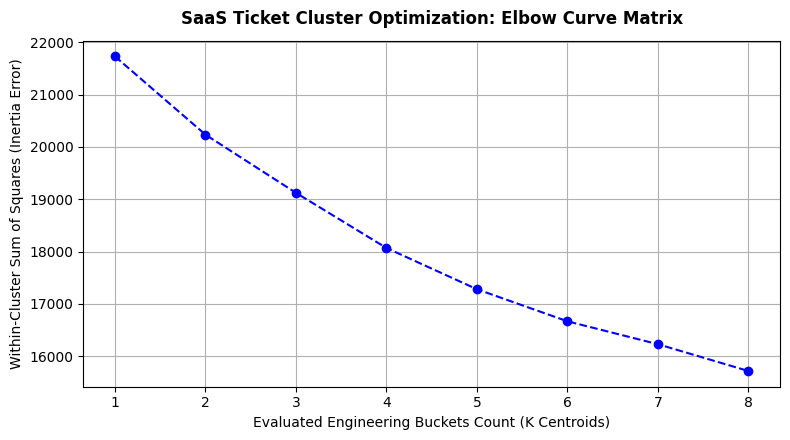

In [25]:
wcss = []
k_range = range(1,9)
for k in k_range:
  kmeans_model = KMeans(n_clusters=k,init="k-means++",random_state=42,n_init=10)
  kmeans_model.fit(tickets_embeddings)

  wcss.append(kmeans_model.inertia_)
  print(f"K: {k} Ineria Score: {kmeans_model.inertia_:.2f}")

plt.figure(figsize=(8, 4.5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='blue', markersize=6)
plt.title('SaaS Ticket Cluster Optimization: Elbow Curve Matrix', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Evaluated Engineering Buckets Count (K Centroids)')
plt.ylabel('Within-Cluster Sum of Squares (Inertia Error)')
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
# k = 4
kmeans_model = KMeans(n_clusters=4,init="k-means++",random_state=42,n_init=10)
df_tickets['cluster_id'] = kmeans_model.fit_predict(tickets_embeddings)

In [27]:
df_tickets.head()

,ticket_id,raw_text,cluster_id
0,TKT_REF_1000,question about cancelling order {{Order Number}},1
1,TKT_REF_1001,i have a question about cancelling oorder {{Or...,1
2,TKT_REF_1002,i need help cancelling puchase {{Order Number}},1
3,TKT_REF_1003,I need to cancel purchase {{Order Number}},1
4,TKT_REF_1004,"I cannot afford this order, cancel purchase {{...",1


Clsuter Mapping

In [28]:
cluster_mapping = {
    0: "Account Access & Authentication Problems",
    1: "Billing, Invoices & Refund Inquiries",
    2: "System Latency & API Performance Degradation",
    3: "Subscription Changes & Feature Access Rights"
}

df_tickets['assigned_domain'] = df_tickets['cluster_id'].map(cluster_mapping)

In [29]:
df_tickets

,ticket_id,raw_text,cluster_id,assigned_domain
0,TKT_REF_1000,question about cancelling order {{Order Number}},1,"Billing, Invoices & Refund Inquiries"
1,TKT_REF_1001,i have a question about cancelling oorder {{Or...,1,"Billing, Invoices & Refund Inquiries"
2,TKT_REF_1002,i need help cancelling puchase {{Order Number}},1,"Billing, Invoices & Refund Inquiries"
3,TKT_REF_1003,I need to cancel purchase {{Order Number}},1,"Billing, Invoices & Refund Inquiries"
4,TKT_REF_1004,"I cannot afford this order, cancel purchase {{...",1,"Billing, Invoices & Refund Inquiries"
...,...,...,...,...
26867,TKT_REF_27867,I am waiting for a rebate of {{Refund Amount}}...,0,Account Access & Authentication Problems
26868,TKT_REF_27868,how to see if there is anything wrong with my ...,0,Account Access & Authentication Problems
26869,TKT_REF_27869,I'm waiting for a reimbjrsement of {{Currency ...,0,Account Access & Authentication Problems
26870,TKT_REF_27870,I don't know what to do to see my reimbursemen...,0,Account Access & Authentication Problems


5. KeyPhrase Extraction

In [30]:
!pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.0 MB/s eta 0:00:00


In [31]:
from keybert import KeyBERT

In [32]:
kw_model = KeyBERT(model=model)

sample = df_tickets['raw_text'].iloc[0]

test_keywords = kw_model.extract_keywords(sample,keyphrase_ngram_range=(1,2),stop_words='english')

print(f"Sample Text: {sample}\nKeywords Extracted: {test_keywords}")

Sample Text: question about cancelling order {{Order Number}}
Keywords Extracted: [('cancelling order', 0.8376), ('order number', 0.6746), ('order order', 0.5945), ('cancelling', 0.5389), ('question cancelling', 0.5213)]


In [33]:
df_tickets["extracted_system_tags"]=[
    [kw[0] for kw in kw_model.extract_keywords(text,keyphrase_ngram_range=(1,2),stop_words='english')]
    for text in df_tickets['raw_text']
]

# print(df_tickets[['raw_text','extracted_system_tags']].head())
df_tickets.head()

,ticket_id,raw_text,cluster_id,assigned_domain,extracted_system_tags
0,TKT_REF_1000,question about cancelling order {{Order Number}},1,"Billing, Invoices & Refund Inquiries","[cancelling order, order number, order order, ..."
1,TKT_REF_1001,i have a question about cancelling oorder {{Or...,1,"Billing, Invoices & Refund Inquiries","[cancelling oorder, oorder order, order number..."
2,TKT_REF_1002,i need help cancelling puchase {{Order Number}},1,"Billing, Invoices & Refund Inquiries","[cancelling puchase, help cancelling, puchase ..."
3,TKT_REF_1003,I need to cancel purchase {{Order Number}},1,"Billing, Invoices & Refund Inquiries","[cancel purchase, need cancel, cancel, purchas..."
4,TKT_REF_1004,"I cannot afford this order, cancel purchase {{...",1,"Billing, Invoices & Refund Inquiries","[order cancel, cancel purchase, purchase order..."


In [34]:
import numpy as np
import json

In [35]:
print("\n--- Step 6: Initializing Routing Engine & Serializing Payloads ---")

processed_ticket_payloads = []

# High-risk trigger flags that drive platform urgency metrics
CRITICAL_TRIGGERS = ["cancel", "refund", "crash", "broken", "freeze", "locked", "error", "timeout", "fail"]

# Process the top 5 tickets to generate a clean, inspectable printout for LinkedIn/Viva
for idx, row in df_tickets.head(5).iterrows():
    text_lower = row['raw_text'].lower()

    # Base priority anchor
    base_urgency = 30

    # 1. Structural length weight calculation
    length_weight = min(len(row['raw_text']) * 0.25, 20)

    # 2. Critical trigger keyword detection
    trigger_hits = sum(1 for trigger in CRITICAL_TRIGGERS if trigger in text_lower)
    trigger_weight = min(trigger_hits * 15, 30)

    # 3. Domain premium assignment (Authentication and Billing take structural precedence)
    category_premium = 20 if row['cluster_id'] in [0, 1] else 0

    # Compile final clip metric bounds
    final_score = int(np.clip(base_urgency + length_weight + trigger_weight + category_premium, 1, 100))

    # Build production webhook tracking JSON structure
    ticket_payload = {
        "ticket_id": row['ticket_id'],
        "raw_complaint_text": row['raw_text'],
        "assigned_engineering_domain": row['assigned_domain'],
        "extracted_system_tags": row['extracted_system_tags'],
        "calculated_priority_score": final_score
    }
    processed_ticket_payloads.append(ticket_payload)

# Render the beautifully clean JSON structures
print("\n================== PRODUCTION WEBHOOK ENGINES OUTPUT ==================")
print(json.dumps(processed_ticket_payloads, indent=2))


--- Step 6: Initializing Routing Engine & Serializing Payloads ---

================== PRODUCTION WEBHOOK ENGINES OUTPUT ==================
[
  {
    "ticket_id": "TKT_REF_1000",
    "raw_complaint_text": "question about cancelling order {{Order Number}}",
    "assigned_engineering_domain": "Billing, Invoices & Refund Inquiries",
    "extracted_system_tags": [
      "cancelling order",
      "order number",
      "order order",
      "cancelling",
      "question cancelling"
    ],
    "calculated_priority_score": 77
  },
  {
    "ticket_id": "TKT_REF_1001",
    "raw_complaint_text": "i have a question about cancelling oorder {{Order Number}}",
    "assigned_engineering_domain": "Billing, Invoices & Refund Inquiries",
    "extracted_system_tags": [
      "cancelling oorder",
      "oorder order",
      "order number",
      "cancelling",
      "oorder"
    ],
    "calculated_priority_score": 79
  },
  {
    "ticket_id": "TKT_REF_1002",
    "raw_complaint_text": "i need help cancelling

In [42]:
import random
import re

def experimental_enterprise_booster(stable_payloads):
    """
    Modular post-processing layer.
    Transforms placeholders to mock data, parses mock IDs, and evaluates SLA triggers.
    """
    boosted_payloads = []


    for ticket in stable_payloads:
        # Creating a deep copy
        boosted_ticket = ticket.copy()
        text = boosted_ticket["raw_complaint_text"]

        # 1. Simulate real-world chaotic SaaS data
        # Check if the text contains a placeholder like {{Order Number}}
        if "{{" in text:
            # Generate a realistic hexadecimal mock ID string
            mock_id = f"HEX_ID_{random.randint(100000, 999999):X}"
            # Swap the bracket placeholders out for the real mock ID string
            processed_text = re.sub(r"\{\{.*?\}\}", mock_id, text)
            boosted_ticket["raw_complaint_text"] = processed_text

            # Simulating an NER/Regex extraction pass to grab that exact ID into its own key
            extracted_id = re.search(r"HEX_ID_[0-9A-F]+", processed_text)
            boosted_ticket["extracted_metadata_keys"] = {
                "system_transaction_id": extracted_id.group(0) if extracted_id else None
            }
        else:
            boosted_ticket["extracted_metadata_keys"] = {"system_transaction_id": None}

        # 2. SLA High-Priority Gateway Alerting
        # If the score hits our threshold, flag it for instant infrastructure paging
        if boosted_ticket["calculated_priority_score"] >= 78:
            boosted_ticket["infrastructure_sla_routing"] = {
                "sla_breach_status": "CRITICAL_ALERT",
                "automated_pager_target": "on-call-backend-pod-alpha",
                "escalation_window": "15_MINUTES_MAX"
            }
        else:
            boosted_ticket["infrastructure_sla_routing"] = {
                "sla_breach_status": "STANDARD_QUEUE",
                "automated_pager_target": "default-support-buffer",
                "escalation_window": "24_HOURS"
            }

        boosted_payloads.append(boosted_ticket)

    return boosted_payloads


experimental_output = experimental_enterprise_booster(processed_ticket_payloads)

print("\n================== BOOSTED WEBHOOK OUTPUT PREVIEW ==================")
print(json.dumps(experimental_output[:3], indent=2))


================== BOOSTED WEBHOOK OUTPUT PREVIEW ==================
[
  {
    "ticket_id": "TKT_REF_1000",
    "raw_complaint_text": "question about cancelling order HEX_ID_6AED0",
    "assigned_engineering_domain": "Billing, Invoices & Refund Inquiries",
    "extracted_system_tags": [
      "cancelling order",
      "order number",
      "order order",
      "cancelling",
      "question cancelling"
    ],
    "calculated_priority_score": 77,
    "extracted_metadata_keys": {
      "system_transaction_id": "HEX_ID_6AED0"
    },
    "infrastructure_sla_routing": {
      "sla_breach_status": "STANDARD_QUEUE",
      "automated_pager_target": "default-support-buffer",
      "escalation_window": "24_HOURS"
    }
  },
  {
    "ticket_id": "TKT_REF_1001",
    "raw_complaint_text": "i have a question about cancelling oorder HEX_ID_52DDF",
    "assigned_engineering_domain": "Billing, Invoices & Refund Inquiries",
    "extracted_system_tags": [
      "cancelling oorder",
      "oorder order",


--- Initializing Confidence Threshold Triage & Visual Validation Engine ---


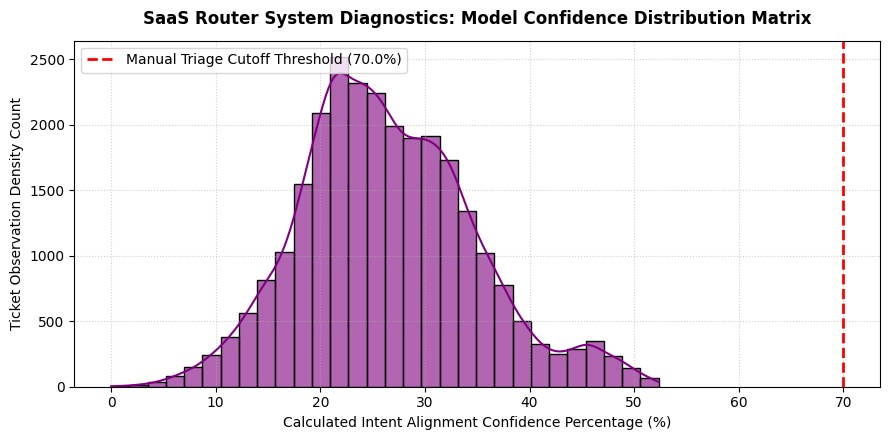


================== SAFETY PAYLOAD TELEMETRY PREVIEW ==================
[
  {
    "ticket_id": "TKT_REF_1000",
    "raw_text": "question about cancelling order {{Order Number}}",
    "model_confidence_percentage": 40.99,
    "execution_status": "ROUTING_HOLD_LOW_CONFIDENCE",
    "final_assigned_target": "Manual Triage Fallback Queue"
  },
  {
    "ticket_id": "TKT_REF_1001",
    "raw_text": "i have a question about cancelling oorder {{Order Number}}",
    "model_confidence_percentage": 40.31,
    "execution_status": "ROUTING_HOLD_LOW_CONFIDENCE",
    "final_assigned_target": "Manual Triage Fallback Queue"
  }
]


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

print("--- Initializing Confidence Threshold Triage & Visual Validation Engine ---")

# 1. Calculate the distance of every single text vector to its assigned cluster center centroid
distances = kmeans_model.transform(tickets_embeddings)
min_distances = np.min(distances, axis=1)

# Inverse normalize the raw distance metrics into a clean 0-100% confidence score spectrum
# Shorter distance to centroid = higher conceptual placement confidence
max_dist = np.max(min_distances)
confidence_scores = (1 - (min_distances / max_dist)) * 100

# Push the metrics straight into our master database tracking frame
df_tickets['confidence_score'] = confidence_scores

# 2. Build the strict 70% Confidence Threshold Safety Valve
CONFIDENCE_THRESHOLD = 70.0

final_payloads_with_safety_valve = []

# Process a quick sampling layout to inspect our telemetry structures
for idx, row in df_tickets.head(5).iterrows():
    raw_confidence = row['confidence_score']

    # Deterministic Business Rule: Fallback route interceptor
    if raw_confidence < CONFIDENCE_THRESHOLD:
        final_route = "Manual Triage Fallback Queue"
        routing_status = "ROUTING_HOLD_LOW_CONFIDENCE"
    else:
        final_route = row['assigned_engineering_bucket']
        routing_status = "AUTOMATED_ROUTING_PROCEEDED"

    payload = {
        "ticket_id": row['ticket_id'],
        "raw_text": row['raw_text'],
        "model_confidence_percentage": round(raw_confidence, 2),
        "execution_status": routing_status,
        "final_assigned_target": final_route
    }
    final_payloads_with_safety_valve.append(payload)

# 3. Generate the High-Yield Portfolio Chart (Distribution Histogram)
plt.figure(figsize=(9, 4.5))
sns.histplot(df_tickets['confidence_score'], bins=30, kde=True, color='purple', alpha=0.6)
plt.axvline(CONFIDENCE_THRESHOLD, color='red', linestyle='--', linewidth=2,
            label=f'Manual Triage Cutoff Threshold ({CONFIDENCE_THRESHOLD}%)')

plt.title('SaaS Router System Diagnostics: Model Confidence Distribution Matrix', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Calculated Intent Alignment Confidence Percentage (%)')
plt.ylabel('Ticket Observation Density Count')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('system_confidence_distribution.png', dpi=300) # Saved straight to your left file panel!
plt.show()

print("\n================== SAFETY PAYLOAD TELEMETRY PREVIEW ==================")
print(json.dumps(final_payloads_with_safety_valve[:2], indent=2))